In [1]:
from dotenv import load_dotenv

_ = load_dotenv()

In [2]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

memory = MemorySaver()

In [3]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [4]:
from langchain_ollama import ChatOllama
model = ChatOllama(model="llama3.1:8b", temperature=0)

In [5]:
PLAN_PROMPT = """당신은 에세이 개요를 작성하는 전문 작가입니다. \
사용자가 제시한 주제에 대한 고수준 개요를 작성하세요. \
각 섹션에 대한 관련 메모나 지침과 함께 개요를 제공하세요. \
반드시 한국어로 작성하세요."""

In [6]:
WRITER_PROMPT = """당신은 5단락 에세이를 탁월하게 작성하는 에세이 작성 보조자입니다. \
사용자의 요청과 초기 개요를 바탕으로 최고의 에세이를 작성하세요. \
사용자가 비평을 제공하면 이전 작성 내용을 수정한 버전으로 응답하세요. \
아래의 모든 정보를 필요에 따라 활용하세요. \
반드시 한국어로 작성하세요.

------

{content}"""

In [7]:
REFLECTION_PROMPT = """당신은 에세이 제출물을 채점하는 교사입니다. \
사용자의 제출물에 대한 비평과 개선 권고사항을 한국어로 작성하세요. \
글의 길이, 깊이, 문체 등에 대한 구체적인 개선 방향을 포함하세요."""

In [8]:
RESEARCH_PLAN_PROMPT = """당신은 에세이 작성에 필요한 정보를 수집하는 연구자입니다. \
아래 에세이 작성에 활용할 수 있는 검색 쿼리 목록을 생성하세요. \
최대 3개의 검색 쿼리만 생성하세요."""


In [9]:
RESEARCH_CRITIQUE_PROMPT = """당신은 에세이 수정에 필요한 정보를 수집하는 연구자입니다. \
아래에 제시된 수정 요청 사항을 반영하기 위한 검색 쿼리 목록을 생성하세요. \
최대 3개의 검색 쿼리만 생성하세요."""


In [10]:
from pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]

In [11]:
from tavily import TavilyClient
import os
tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [12]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [13]:
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state.get('content') or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r.get('content', ''))
    return {"content": content}

In [14]:
def generation_node(state: AgentState):
    content = "\n\n".join(state['content'] or [])
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
        ]
    response = model.invoke(messages)
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1
    }


In [15]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [16]:
def research_critique_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state.get('content') or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r.get('content', ''))
    return {"content": content}

In [17]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [18]:
builder = StateGraph(AgentState)

In [19]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [20]:
builder.set_entry_point("planner")

In [21]:
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END, "reflect": "reflect"}
)


In [22]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [23]:
graph = builder.compile(checkpointer=memory)

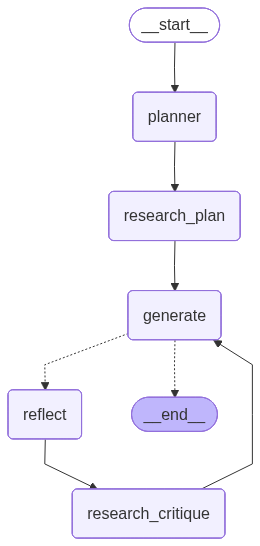

In [24]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [25]:
thread = {"configurable": {"thread_id": "2"}}
for s in graph.stream({
    'task': "한국과 일본의 차이는",
    "max_revisions": 2,
    "revision_number": 1,
}, thread):
    print(s)

{'planner': {'plan': '**주제: 한국과 일본의 차이**\n\n**개요:**\n\n한국과 일본은 동아시아에서 두 나라로, 역사적, 문화적, 사회적으로 많은 차이를 보입니다. 이 에세이는 한국과 일본의 주요 차이점을 고찰하고, 각국의 특징을 분석합니다.\n\n**I. 역사적 배경**\n\n*   한국은 3천년 전부터 한민족이 정착한 곳으로, 고대에는 백제, 신라, 가야 등 세 나라로 분열되어 있었다.\n*   일본은 5세기 초에 중국에서 유입된 야마토 왕조가 건국하여, 이후에도 중국과 교류를 하면서 발전했다.\n\n**II. 문화적 차이**\n\n*   한국의 전통 음악은 가야금, 북, 장구 등으로, 일본의 전통 음악은 shamisen, koto 등으로 구성된다.\n*   한국의 전통 의상은 한복, 일본의 전통 의상은 kimono로, 두 나라 모두 아름다운 디자인과 색상을 특징으로 한다.\n\n**III. 사회적 차이**\n\n*   한국은 가족을 중시하는 사회로, 일본도 가족을 중요하게 생각하지만, 더 강한 집단주의를 보인다.\n*   한국의 교육 시스템은 미국식으로, 일본의 교육 시스템은 유럽식으로 구성된다.\n\n**IV. 경제적 차이**\n\n*   한국은 1960년대에 급격히 경제가 성장하여, 현재는 세계 11위의 경제력을 자랑한다.\n*   일본도 1950년대부터 경제가 성장하여, 현재는 세계 3위의 경제력을 보유하고 있다.\n\n**V. 결론**\n\n한국과 일본은 역사적, 문화적, 사회적으로 많은 차이를 보이고 있지만, 두 나라 모두 동아시아에서 중요한 역할을 하고 있다.'}}
{'research_plan': {'content': ['그러나 그 격차는 줄어들고 있다! 요즘 가장 큰 이슈는 역시 **일본경제보복**입니다. 오늘은 부동산 얘기가 아닌 개인적인 호기심에 하는 포스팅입니다. 객관적인 지표로 한국과 일본을 살펴볼게요. | 국토면적 | 1002만 9535ha(세계 107위) | 3779만 7100ha(세계 61위) |. | G